# Exercise: Physics-Informed Neural Networks (PINNs)


This notebook is an adaptation of Ben Mosley's 2022 [workshop on PINNs](https://github.com/benmoseley/harmonic-oscillator-pinn-workshop). The workshop builds upon a [blog post](https://benmoseley.blog/my-research/so-what-is-a-physics-informed-neural-network/) on PINNs of the same author.

The workshop will introduce you to PINNs and how to code them in `PyTorch` using the classical ODE example of the **damped harmonic oscillator**.

Proceed through the *Walkthrough*, and then try to work on the *Assignment*.

## Walkthrough

### Problem overview

We are going to use a PINN to solve problems related to the **1D damped harmonic oscillator**:

<img src="https://benmoseley.blog/wp-content/uploads/2021/08/oscillator.gif" width="500">

We are interested in modelling the displacement of the mass on a spring (green box) over time.

This is a canonical physics problem, where the displacement, $u(t)$, of the oscillator as a function of time can be described by the following differential equation:

$$
m \dfrac{d^2 u}{d t^2} + \mu \dfrac{d u}{d t} + ku = 0~,
$$

where $m$ is the mass of the oscillator, $\mu$ is the coefficient of friction and $k$ is the spring constant.

We will focus on solving the problem in the **under-damped state**, i.e. where the oscillation is slowly damped by friction (as displayed in the animation above).

Mathematically, this occurs when:

$$
\delta < \omega_0~,~~~~~\mathrm{where}~~\delta = \dfrac{\mu}{2m}~,~\omega_0 = \sqrt{\dfrac{k}{m}}~.
$$

Furthermore, we consider the following initial conditions of the system:

$$
u(t=0) = 1~~,~~\dfrac{d u}{d t}(t=0) = 0~.
$$

For this particular case, the exact solution is known and given by:

$$
u(t) = e^{-\delta t}(2 A \cos(\phi + \omega t))~,~~~~~\mathrm{with}~~\omega=\sqrt{\omega_0^2 - \delta^2}~.
$$



For a more detailed mathematical description of the harmonic oscillator, check out this blog post: https://beltoforion.de/en/harmonic_oscillator/.

### Tasks in the walkthrough



There are **three tasks** related to the harmonic oscillator we will use a PINN for:

- First, we will **simulate** the system using a PINN, given its initial conditions.

- Second, we will **invert** for underlying parameters of the system using a PINN, given some noisy observations of the oscillator's displacement.

- Finally, we will investigate how well the PINN **scales** to higher frequency oscillations and what can be done to improve its convergence.

### Initial setup


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt


First, we define a few helper functions.

In [2]:
def exact_solution(d, w0, t):
    "Defines the analytical solution to the under-damped harmonic oscillator problem above."
    assert d < w0
    w = np.sqrt(w0**2-d**2)
    phi = np.arctan(-d/w)
    A = 1/(2*np.cos(phi))
    cos = torch.cos(phi+w*t)
    exp = torch.exp(-d*t)
    u = exp*2*A*cos
    return u

class MLP(nn.Module):
    "Defines a basic multi-layer perceptron."
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        # Define the layers of the network
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Define the forward pass
        x = F.tanh(self.fc1(x))  # Activation function (ReLU) after first layer
        x = F.tanh(self.fc2(x))  # Activation function (ReLU) after second layer
        x = self.fc3(x)          # Output layer
        return x

### Task 1: train a PINN to simulate the system



The first task is to use a PINN to **simulate** the system.

Specifically, our inputs and outputs are:

- Inputs: the initial conditions of the system, the underlying ODE, and some points in time (the independent variable) where we want to estimate how well the output of the PINN satisfies the ODE.
- Outputs: estimate of the solution, $u(t)$

#### Approach

The PINN is trained to directly approximate the solution to the differential equation, i.e.

$$
u_{\mathrm{PINN}}(t;\theta) \approx u(t)~,
$$

where $\theta$ are the free parameters of the PINN.

#### Loss function

To simulate the system, the PINN is trained with the following loss function:

$$
\mathcal{L}(\theta)= (u_{\mathrm{PINN}}(t=0;\theta) - 1)^2 + \lambda_1 \left(\frac{d\,u_{\mathrm{PINN}}}{dt}(t=0;\theta) - 0\right)^2 + \frac{\lambda_2}{N} \sum^{N}_{i} \left( \left[ m\frac{d^2}{dt^2} + \mu \frac{d}{dt} + k \right] u_{\mathrm{PINN}}(t_{i};\theta)  \right)^2
$$

For this task, we use $\delta=2$, $\omega_0=20$, and try to learn the solution over the domain $t\in [0,1]$.

#### Notes

- The first two terms in the loss function represent the **boundary loss**, and tries to ensure that the solution learned by the PINN matches the initial conditions of the system, namely, $u(t=0)=1$ and $u'(t=0)=0$.

- The third term in the loss function is called the **physics loss**, and and tries to ensure that the PINN solution obeys the underlying differential equation at a set of *training points* $t_i\in [0,1]$. The training points $\{t_i\}$ are just a set of sampled points from this domain. Unlike traditional supervised learning where each input $x$ has a corresponding target $y$, in some cases PINNs may work without explicit output data for each input. This is because they can rely on the physics of the problem, expressed through differential equations, to guide the learning process.

- The physics loss is based on an ODE that equals zero when the system’s behavior is perfectly modeled. Unlike initial conditions with defined targets (i.e., 1 and 0, respectively), this term’s correctness is fulfilled when the expression evaluates to zero. This is why in the loss we explicitly subtract 1 and 0 for the boundary terms, but we avoid subtracting 0 from the physics term.  

- The hyperparameters, $\lambda_1$ and $\lambda_2$, are used to balence the terms in the loss function, to ensure stability during training.

- Autodifferentiation (`torch.autograd`) is used to calculate the gradients of the PINN with respect to its input required to evaluate the loss function. This is very powerful!

For more details on `torch.autograd`, check out [this](https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html#a-gentle-introduction-to-torch-autograd) tutorial.

In [3]:
# set the seed for reproducibility
torch.manual_seed(123)

# define a neural network to train
pinn = MLP(1,128,1)

# define boundary points, for the boundary loss
t_boundary = torch.tensor(0.).view(-1,1).requires_grad_(True)

# define training points over the entire domain, for the physics loss
n_points = 100
t_physics = torch.linspace(0,1,n_points).view(-1,1).requires_grad_(True)

# setup to train the PINN
n_epochs = 15001
d, w0 = 2, 20
mu, k = 2*d, w0**2
t_test = torch.linspace(0,1,n_points).view(-1,1)
u_exact = exact_solution(d, w0, t_test)
optimiser = torch.optim.Adam(pinn.parameters(),lr=1e-3)

# compute each term of the PINN loss function using the following hyperparameters:
lambda1, lambda2 = 1e-1, 1e-4

# echo on screen
echo_every = 5000

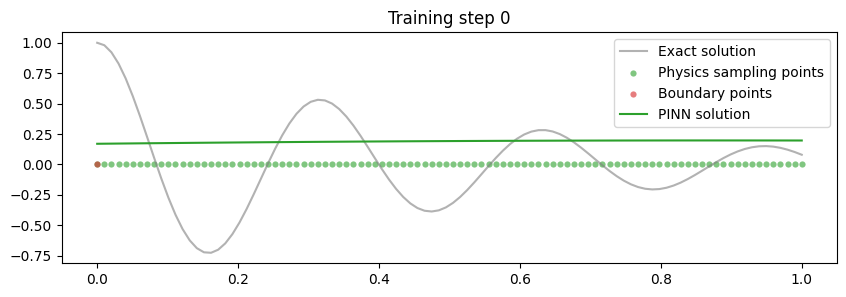

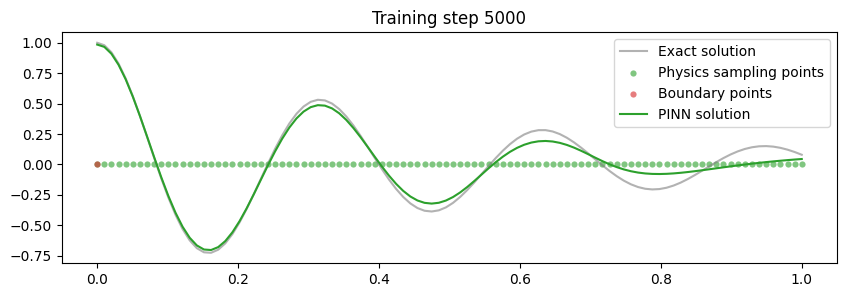

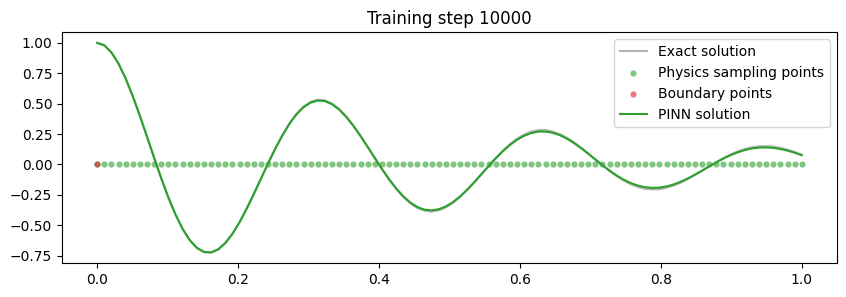

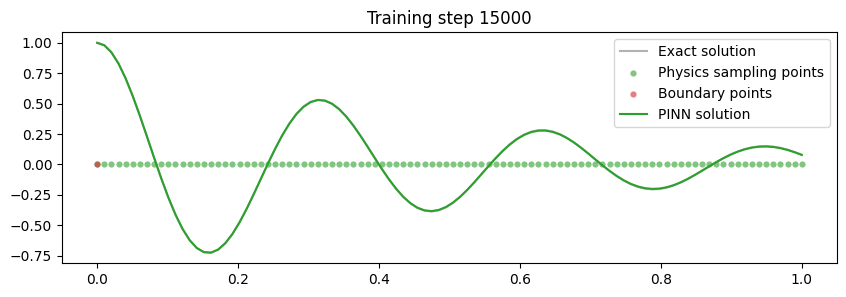

In [4]:
for i in range(n_epochs+1):
    optimiser.zero_grad()

    # compute boundary loss
    u = pinn(t_boundary)
    loss1 = (torch.squeeze(u) - 1)**2
    dudt = torch.autograd.grad(u, t_boundary, torch.ones_like(u), create_graph=True)[0]
    loss2 = (torch.squeeze(dudt) - 0)**2

    # compute physics loss
    u = pinn(t_physics)
    dudt = torch.autograd.grad(u, t_physics, torch.ones_like(u), create_graph=True)[0]
    d2udt2 = torch.autograd.grad(dudt, t_physics, torch.ones_like(dudt), create_graph=True)[0]
    loss3 = torch.mean((d2udt2 + mu*dudt + k*u)**2)

    # backpropagate joint loss, take optimiser step
    loss = loss1 + lambda1*loss2 + lambda2*loss3
    loss.backward()
    optimiser.step()

    # plot the result as training progresses
    if i % echo_every == 0:
        #print(u.abs().mean().item(), dudt.abs().mean().item(), d2udt2.abs().mean().item())
        u = pinn(t_test).detach()
        plt.figure(figsize=(10,3))
        plt.plot(t_test[:,0], u_exact[:,0], label="Exact solution", color="tab:grey", alpha=0.6)
        plt.scatter(t_physics.detach()[:,0],
                    torch.zeros_like(t_physics)[:,0], label="Physics sampling points", s=20, lw=0, color="tab:green", alpha=0.6)
        plt.scatter(t_boundary.detach()[:,0],
                    torch.zeros_like(t_boundary)[:,0], label="Boundary points", s=20, lw=0, color="tab:red", alpha=0.6, )
        plt.plot(t_test[:,0], u[:,0], label="PINN solution", color="tab:green")
        plt.title(f"Training step {i}")
        plt.legend()
        plt.show()

### Task 2: train a PINN to invert for underlying parameters


The second task is to use a PINN to **invert** for underlying parameters. Inversion involves using the observable data (i.e., measured oscillator's displacement in time) to work backwards and infer the values of the unknown  parameters governing the phenomenon (e.g.,  the coefficient of friction $\mu$ or the spring constant $k$). The PINN is trained so that its output, when fed with the input data (displacements), aligns with the physics of the system encoded in the network, thereby estimating the unknown parameter (e.g., $\mu\$).

Specifically, our inputs and outputs are:

- Inputs: noisy observations of the oscillator's displacement and underlying differential equation, sampled at specific times.
- Outputs: estimate $\mu$, the coefficient of friction.

#### Approach

Similar to above, the PINN is trained to directly approximate the solution to the differential equation, i.e.

$$
u_{\mathrm{PINN}}(t;\theta) \approx u(t)~,
$$

where $\theta$ are the free parameters of the PINN.

The key idea here is to also treat $\mu$ as a **learnable parameter** when training the PINN - so that we both simulate the solution and invert for this parameter.

#### Loss function

The PINN is trained with a slightly different loss function:

$$
\mathcal{L}(\theta, \mu)= \frac{1}{N} \sum^{N}_{i} \left( \left[ m\frac{d^2}{dt^2} + \mu \frac{d}{dt} + k \right] u_{\mathrm{PINN}}(t_{i};\theta)  \right)^2 + \frac{\lambda}{M} \sum^{M}_{j} \left( u_{\mathrm{PINN}}(t_{j};\theta) - u_{\mathrm{obs}}(t_{j}) \right)^2
$$

#### Notes

There are two terms in the loss function here. The first is the **physics loss**, formed in the same way as above, which ensures the solution learned by the PINN is consistent with the know physics.

The second term is called the **data loss**, and makes sure that the solution learned by the PINN fits the (potentially noisy) observations of the solution that are available.

Note, we have removed the boundary loss terms, as we do not know these (i.e., we are only given the observed measurements of the system).

In this set up, the PINN parameters $\theta$ and $\mu$ are **jointly** learned during optimisation.

Again, autodifferentiation is our friend and will allow us to easily define this problem!

True value of mu: 4


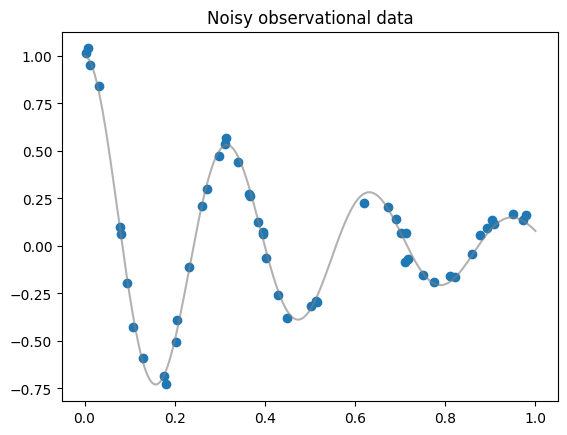

In [16]:
# first, create some noisy observational data
torch.manual_seed(343112)
d, w0 = 2, 20
print(f"True value of mu: {2*d}")
n_obs = 50
t_obs = torch.rand(n_obs).view(-1,1)
u_obs = exact_solution(d, w0, t_obs) + 0.04*torch.randn_like(t_obs)

plt.figure()
plt.title("Noisy observational data")
plt.scatter(t_obs[:,0], u_obs[:,0])
t_test  = torch.linspace(0,1,300).view(-1,1)
u_exact = exact_solution(d, w0, t_test)
plt.plot(t_test[:,0], u_exact[:,0], label="Exact solution", color="tab:grey", alpha=0.6)
plt.show()

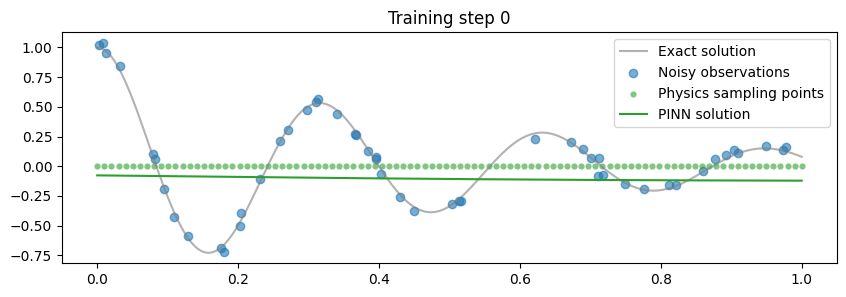

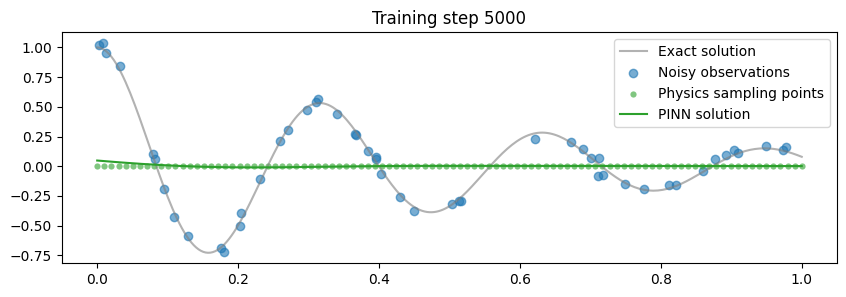

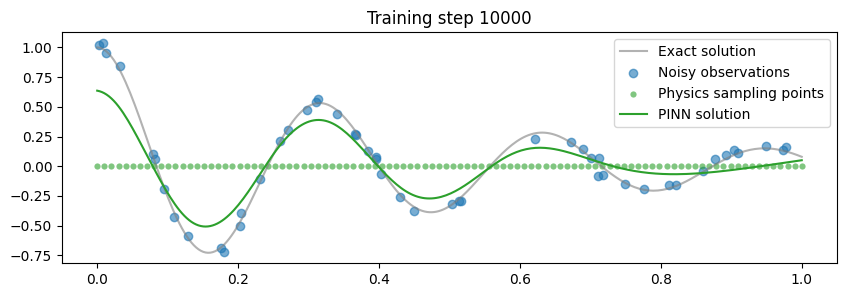

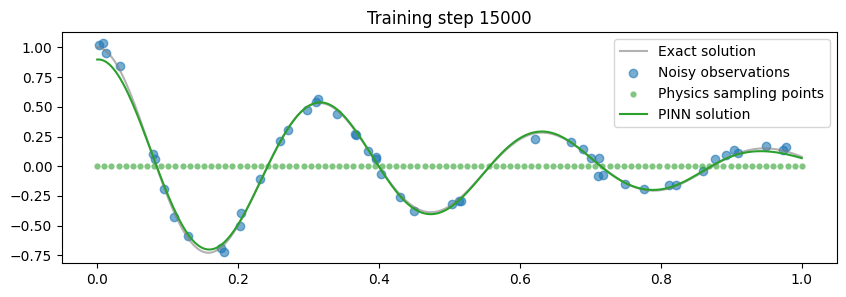

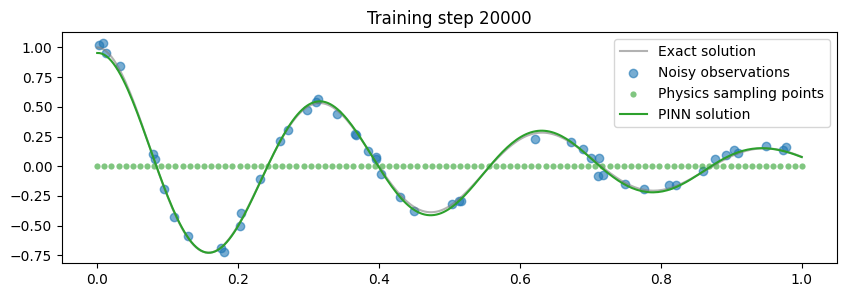

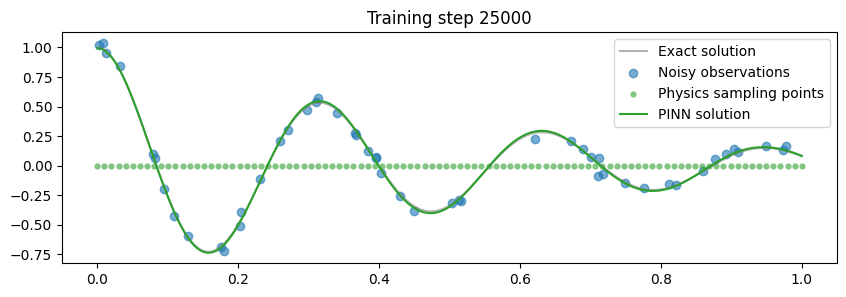

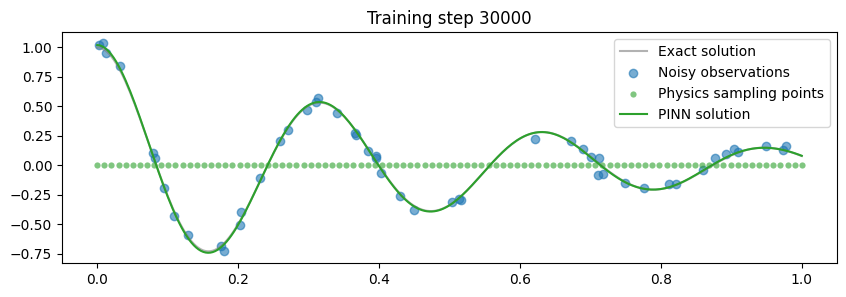

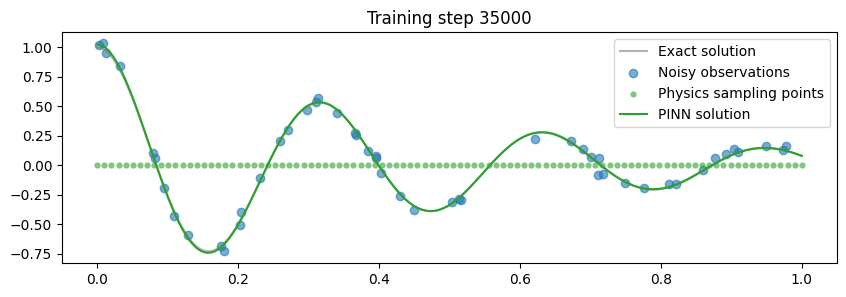

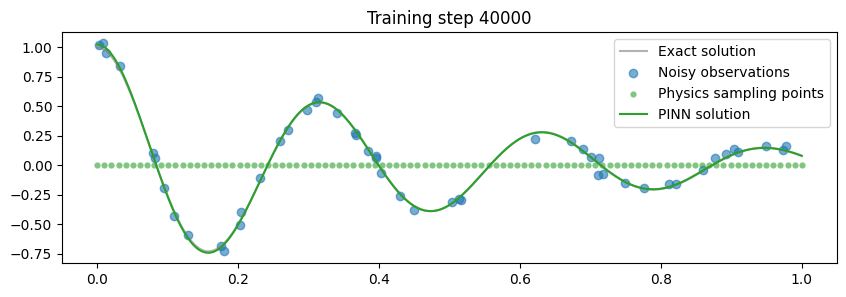

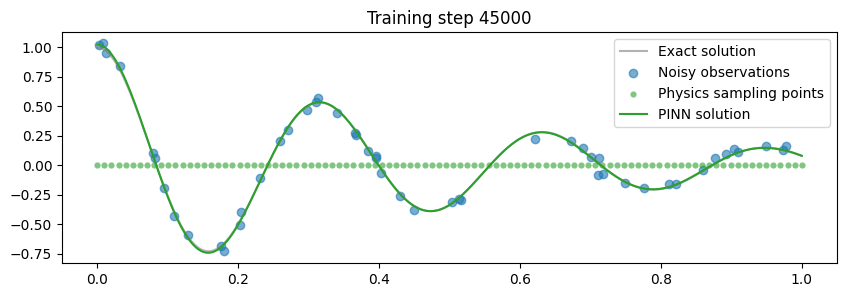

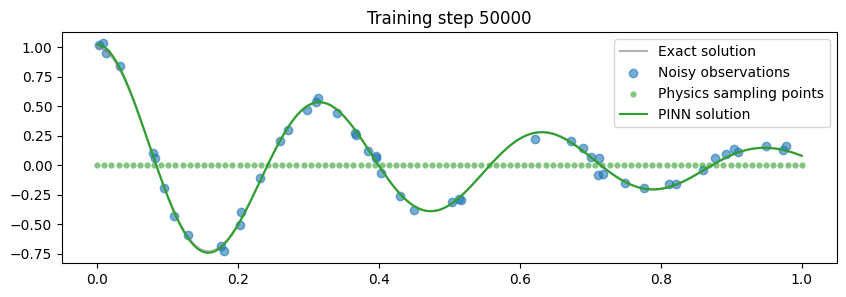

In [25]:
# define a neural network to train
pinn = MLP(1,64,1)

# define training points over the entire domain, for the physics loss
n_points = 100
t_physics = torch.linspace(0,1,n_points).view(-1,1).requires_grad_(True)

# train the PINN
d, w0 = 2, 20
_, k = 2*d, w0**2
# using the following hyperparameters:
lambda1 = 1e4

# treat mu as a learnable parameter
mu = torch.nn.Parameter(torch.ones(1, requires_grad=True))
mus = []

n_epochs = 50001
echo_every = 5000

## Lists to store losses (uncomment if you want to store losses)
# physics_losses = []
# data_losses = []
# total_losses = []

# add mu to the optimiser
optimiser = torch.optim.Adam(list(pinn.parameters())+[mu],lr=1e-4)
for i in range(n_epochs):
    optimiser.zero_grad()

    # compute physics loss
    u = pinn(t_physics)
    dudt = torch.autograd.grad(u, t_physics, torch.ones_like(u), create_graph=True)[0]
    d2udt2 = torch.autograd.grad(dudt, t_physics, torch.ones_like(dudt), create_graph=True)[0]
    loss1 = torch.mean((d2udt2 + mu*dudt + k*u)**2)

    # compute data loss
    u = pinn(t_obs)
    loss2 = torch.mean((u - u_obs)**2)

    # backpropagate joint loss, take optimiser step
    loss = loss1 + lambda1*loss2
    loss.backward()
    optimiser.step()

    # record mu value
    mus.append(mu.item())

    ## record losses (uncomment if you want to store losses)
    #physics_losses.append(loss1.item())
    #data_losses.append(loss2.item())
    #total_losses.append(loss.item())

    # plot the result as training progresses
    if i % echo_every == 0:
        u = pinn(t_test).detach()
        plt.figure(figsize=(10,3))
        plt.plot(t_test[:,0], u_exact[:,0], label="Exact solution", color="tab:grey", alpha=0.6)
        plt.scatter(t_obs[:,0], u_obs[:,0], label="Noisy observations", alpha=0.6)
        plt.scatter(t_physics.detach()[:,0],
                    torch.zeros_like(t_physics)[:,0], label="Physics sampling points", s=20, lw=0, color="tab:green", alpha=0.6)
        plt.plot(t_test[:,0], u[:,0], label="PINN solution", color="tab:green")
        plt.title(f"Training step {i}")
        plt.legend()
        plt.show()

Text(0, 0.5, '$\\mu$ estimate')

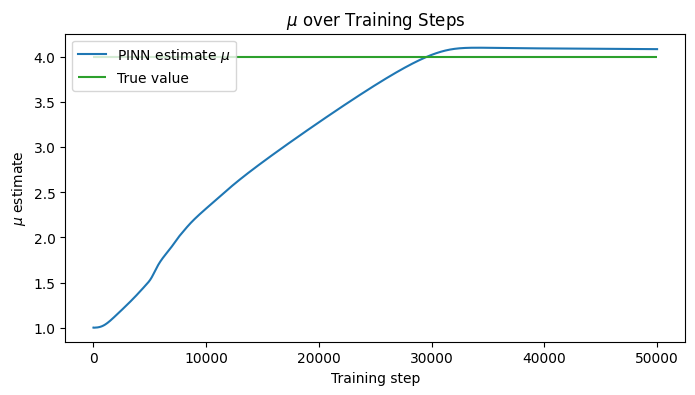

In [30]:
# After training, plot mu estimates and true value
plt.figure(figsize=(8,4))
plt.title("$\mu$ over Training Steps")
mu_line, = plt.plot(mus, label="PINN estimate $\mu$", color="tab:blue")
true_value_line = plt.hlines(2*d, 0, len(mus), label="True value", color="tab:green")
plt.legend(loc='upper left')
plt.xlabel("Training step")
plt.ylabel("$\mu$ estimate")

## Task 3: investigate how well the PINN scales to higher frequency oscillations



The final task is to investigate how well the PINN **scales** to higher frequency oscillations and what can be done to improve its convergence.

Specifically, we go back to simulating the solution to the harmonic oscillator, and increase its frequency, $\omega_0$.

#### To do

>To do: Go back to Task 1 above, and see what happens when you **increase** $\omega_0$ from 20 to 80.

You should find that the PINN struggles to converge, even if the number of physics training points is increased.

This is a harder problem for the PINN to solve, in part because of the **spectral bias** of neural networks, as well as the fact more training points are required.

#### Approach: alternative "ansatz" formulation
> An [ansatz](https://en.wikipedia.org/wiki/Ansatz) refers to an educated guess or a hypothesis about the form or structure of the solution to a differential equation. It's a kind of preliminary assumption or a specific functional form that is chosen based on physical intuition, prior knowledge, or empirical evidence about the nature of the problem being solved.

To speed up convergence, one way is to **assume something** about the solution.

For example, suppose we know from our physics intuition that the solution is in fact sinusodial.

Then, instead of having the PINN directly approximate the solution to the differential equation, i.e.

$$
u_{\mathrm{PINN}}(t;\theta) \approx u(t)~,
$$

We instead use the PINN as part of a mathematical ansatz of the solution, i.e.

$$
\hat u(t; \theta, \alpha, \beta) = u_{\mathrm{PINN}}(t;\theta)  \sin (\alpha t + \beta) \approx u(t)~,
$$

where $\alpha, \beta$ are treated as additional learnable parameters.

Comparing this ansatz to the exact solution

$$
u(t) = e^{-\delta t}(2 A \cos(\phi + \omega t))
$$

We see that now the PINN only needs to learn the exponential function, which should be a much easier problem.

Again, autodifferentiation allows us to easily differentiate through this ansatz to train the PINN!

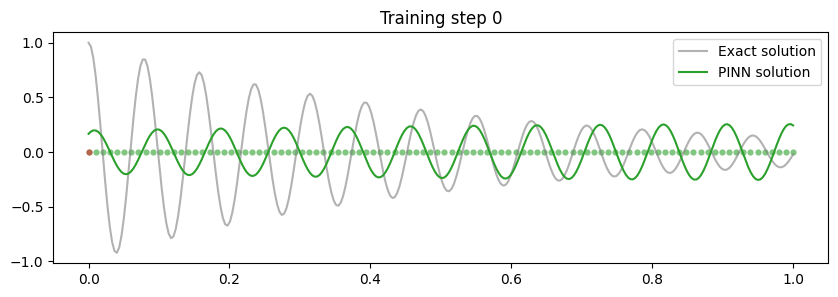

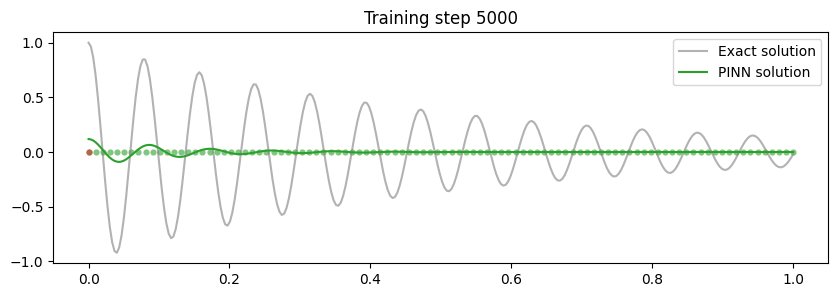

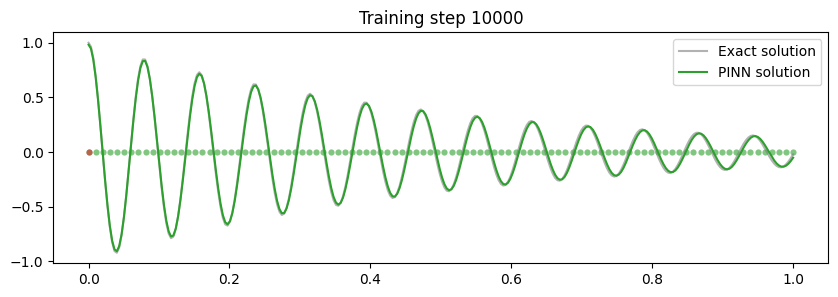

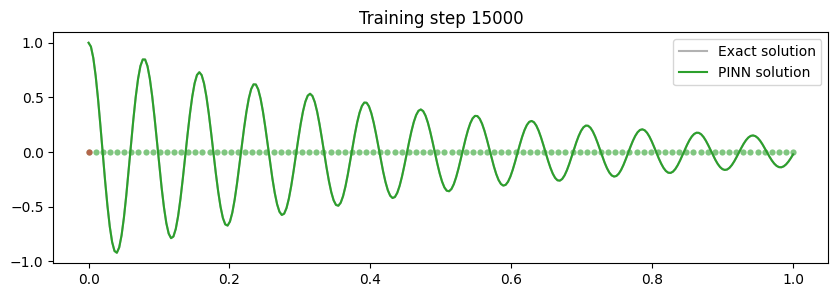

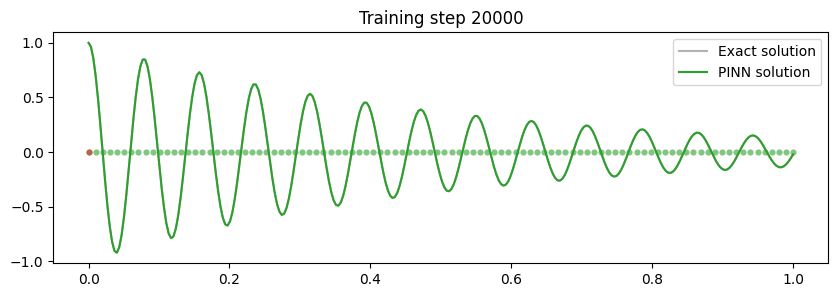

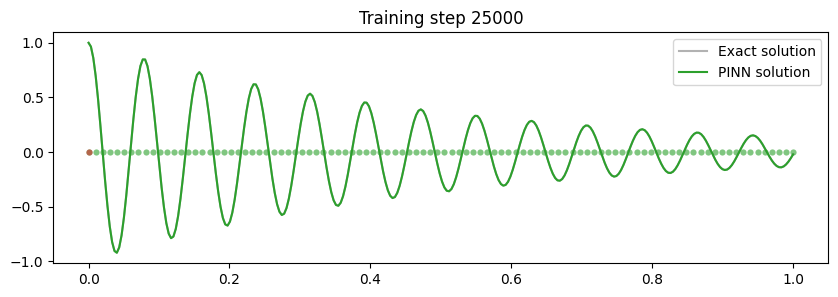

In [27]:
torch.manual_seed(123)

# define a neural network to train
pinn = MLP(1,128,1)

# define additional a,b learnable parameters in the ansatz
a = torch.nn.Parameter(70*torch.ones(1, requires_grad=True))
b = torch.nn.Parameter(torch.ones(1, requires_grad=True))

# define boundary points, for the boundary loss
t_boundary = torch.tensor(0.).view(-1,1).requires_grad_(True)

# define training points over the entire domain, for the physics loss
n_points = 100
t_physics = torch.linspace(0,1,n_points).view(-1,1).requires_grad_(True)

# train the PINN
d, w0 = 2, 80# note w0 is higher!
mu, k = 2*d, w0**2
# using the following hyperparameters:
lambda1, lambda2 = 1e-1, 1e-4

t_test = torch.linspace(0,1,300).view(-1,1)
u_exact = exact_solution(d, w0, t_test)

n_epochs = 25001
echo_every = 5000

# add a,b to the optimiser
optimiser = torch.optim.Adam(list(pinn.parameters())+[a,b],lr=1e-3)
for i in range(n_epochs):
    optimiser.zero_grad()

    # compute boundary loss
    u = pinn(t_boundary)*torch.sin(a*t_boundary+b)
    loss1 = (torch.squeeze(u) - 1)**2
    dudt = torch.autograd.grad(u, t_boundary, torch.ones_like(u), create_graph=True)[0]
    loss2 = (torch.squeeze(dudt) - 0)**2

    # compute physics loss
    u = pinn(t_physics)*torch.sin(a*t_physics+b)
    dudt = torch.autograd.grad(u, t_physics, torch.ones_like(u), create_graph=True)[0]
    d2udt2 = torch.autograd.grad(dudt, t_physics, torch.ones_like(dudt), create_graph=True)[0]
    loss3 = torch.mean((d2udt2 + mu*dudt + k*u)**2)

    # backpropagate joint loss, take optimiser step
    loss = loss1 + lambda1*loss2 + lambda2*loss3
    loss.backward()
    optimiser.step()

    # plot the result as training progresses
    if i % echo_every == 0:
        #print(u.abs().mean().item(), dudt.abs().mean().item(), d2udt2.abs().mean().item())
        u = (pinn(t_test)*torch.sin(a*t_test+b)).detach()
        plt.figure(figsize=(10, 3))
        plt.scatter(t_physics.detach()[:,0],
                    torch.zeros_like(t_physics)[:,0], s=20, lw=0, color="tab:green", alpha=0.6)
        plt.scatter(t_boundary.detach()[:,0],
                    torch.zeros_like(t_boundary)[:,0], s=20, lw=0, color="tab:red", alpha=0.6)
        plt.plot(t_test[:,0], u_exact[:,0], label="Exact solution", color="tab:grey", alpha=0.6)
        plt.plot(t_test[:,0], u[:,0], label="PINN solution", color="tab:green")
        plt.title(f"Training step {i}")
        plt.legend()
        plt.show()

## Assignments


1. **Solving the simulation task for higher $\omega_0$**: You saw that solving the problem for higer $\omega_0$ is more difficult. What can you do to improve convergence? Try to provide more sampling data points, a more complext network architecture, or change hyperameters, including the weights that you use to balance the different terms of the loss.

2. **Experiment with the inversion task**: See how far you can push the inversion task:
  - Can you discover the true value of $\mu$?
  - Can you discover the values of $m$, $\mu$ and $k$ simultaneously, and therefore, reveal the entire underlying equation?

3. **MLP vs PINN**: In class you saw how PINNs can generalize much better than simple MLPs with limited data point. Try recreating that experiment on your own. In particular:
  - Create a small training dataset (i.e., 10 data points) that covers only one-third of the domain, i.e., $t\in [0,0.33]$. Use the rest of the domain to create validation data points.
  - Train a MLP to fit these training data points and then check the validation performance.
  - Train a PINN using the same labeled data points, but also a physics-informed loss that exploits sampling points across the entire domain.   
  - Train another PINN, but this time with a wrong physics-informed loss (e.g., wrong underlying equations). What happens to the model performance?
  - You can refer to this notebook [here](https://github.com/benmoseley/harmonic-oscillator-pinn/blob/main/Harmonic%20oscillator%20PINN.ipynb) if you need help.